## Dust Scattering Halo Ray Tracing

- `device.py` — reports which JAX backend/GPU is in use.
- `voxels.py` — builds and indexes the 3D voxel density grid (sphere/slab/FITS-derived).
- `raytracing.py` — ray-box intersection and angle-to-direction geometry.
- `sampling.py` — random draws: free path, and isotropic/Rayleigh/Mie scattering angles.
- `transport.py` — the per-photon physics step and the vmap/scan/jit simulation loop.
- `geometry.py` — extracts a few example photon paths from simulation output for plotting.
- `plotting.py` — matplotlib helpers for all the notebook's charts and 3D scenes.
- `fits_cube.py` — reads, prints, and plots a real FITS column-density cube.


### Import Libraries

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt

from utils.device import print_device_report
from utils import sampling, raytracing, voxels, transport, geometry, plotting, fits_cube


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1788620520.071620  621759 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1788620520.088398  621759 service.cc:145] XLA service 0x7a0e52900 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788620520.088407  621759 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1788620520.089486  621759 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1788620520.089494  621759 mps_client.cc:384] XLA backend will use up to 14301773824 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M3 Pro

systemMemory: 18.00 GB
maxCacheSize: 6.66 GB



### Determine device. I set it up for Nvidia GPU and Macbook Pro M3 Chip for now.

In [2]:

plt.rcParams["figure.figsize"] = (6, 4)

_ = print_device_report()

JAX backend : METAL
Devices     : [METAL(id=0)]


### I get the FITS cloud file, analyze it first.

Filename: realistic_nh_cube_500asec_10kpc_dz0p05.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  TOTAL_NH      1 PrimaryHDU      44   (500, 500, 200)   float32   
  1  NH_MAP        1 ImageHDU        24   (500, 500)   float32   
  2  HI_NH_MAP     1 ImageHDU        24   (500, 500)   float32   
  3  MOL_NH_MAP    1 ImageHDU        24   (500, 500)   float32   
  4  MC1_NH        1 ImageHDU        25   (500, 500)   float32   
  5  MC2_NH        1 ImageHDU        25   (500, 500)   float32   
  6  MC3_NH        1 ImageHDU        25   (500, 500)   float32   
  7  MC4_NH        1 ImageHDU        25   (500, 500)   float32   
  8  CLOUDS        1 BinTableHDU     50   4R x 14C   [16A, D, D, D, D, D, D, D, D, D, D, J, J, K]   

--- TOTAL_NH ---
  shape: (200, 500, 500)   dtype: >f4   unit: cm-2
  min=1.6054e+19  max=4.5683e+22  mean=1.1812e+20
  BTYPE: DELTA_NH
  SIMTYPE: TURBULENT
  NMCLOUD: 4
  ZMINKPC: 0.0
  ZMAXKPC: 10.0
  DZKPC: 0.05

--- NH_MAP ---
  shape: (500, 500

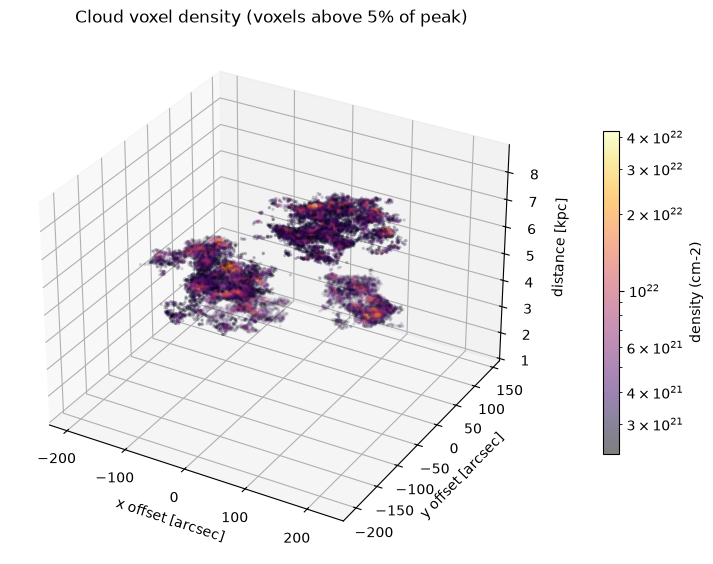

In [3]:
from utils import fits_cube
import matplotlib.pyplot as plt

path = "realistic_nh_cube_500asec_10kpc_dz0p05.fits"

# 1. Dump everything the FITS file contains (all HDUs, header keywords, the CLOUDS table)
fits_cube.print_fits_info(path)

# 2. Load the main density cube + its physical axes (arcsec, arcsec, kpc)
cube = fits_cube.load_cube(path)

# 3. Quick stats: grid shape, extent, density range, nonzero fraction
fits_cube.print_cube_summary(cube)

# 4. 3D plot of the cloud, colored/sized by density (log scale)
fits_cube.plot_cloud_3d(cube, density_threshold_frac=0.05)
plt.show()

### I downsize the cloud for now. When we run on a GPU, we can keep it as it is.

In [4]:
# 1. real cloud -> a faint (optically thin) scattering screen
cube = fits_cube.load_cube("realistic_nh_cube_500asec_10kpc_dz0p05.fits")
N_VOXELS = 30
density_grid, box_min, box_max = voxels.from_fits_cube(cube, n_voxels=N_VOXELS, peak_density=0.02)
print("Cloud downsized with from_fits_cube.")
print("Density grid is the cloud.")
print("box_min and box_max are simulation boundaries.")

Cloud downsized with from_fits_cube.
Density grid is the cloud.
box_min and box_max are simulation boundaries.


In [5]:
# 2. aim the pencil beam at the resampled grid's own density peak, not the box center --
#    from_fits_cube discards the FITS's arcsec/kpc coordinates when remapping onto the plain box
peak_idx = np.unravel_index(np.argmax(np.asarray(density_grid)), density_grid.shape)
voxel_size = (np.asarray(box_max) - np.asarray(box_min)) / N_VOXELS
aim_point = jnp.array(np.asarray(box_min) + (np.array(peak_idx) + 0.5) * voxel_size)
print("Here we find the densest voxel in the cloud. Set it to peak_idx.")
print("We aim our photons to this point (aim_point) for now. We will change this later.")

Here we find the densest voxel in the cloud. Set it to peak_idx.
We aim our photons to this point (aim_point) for now. We will change this later.


In [6]:
# 3. grain + energy assumption -> deep in the Mie (forward-peaked) regime, as established earlier
GRAIN_RADIUS_UM = 0.1
ENERGY_KEV = 1.0
x = sampling.size_parameter_from_energy_kev(ENERGY_KEV, GRAIN_RADIUS_UM)
print("We set grain radius to a fixed size. For now it is 0.1 micrometers.")
print("We set photons to a fixed energy 1KeV.")
print("We set x (size parameter) to 2π·grain_radius/wavelength with size_parameter_from_energy_kev.\nNot to be " \
"confused with x the cloud distance ratio.")

We set grain radius to a fixed size. For now it is 0.1 micrometers.
We set photons to a fixed energy 1KeV.
We set x (size parameter) to 2π·grain_radius/wavelength with size_parameter_from_energy_kev.
Not to be confused with x the cloud distance ratio.


In [7]:
# 4. point-source pencil beam through the cloud
simulate_photons_jit = jax.jit(transport.simulate_photons,
    static_argnames=("n_photons", "n_bounces", "n_substeps", "scattering_model"))
print("""
Compiles simulate_photons into a fast kernel for the GPU/CPU, so the whole batched
simulation runs as one compiled program instead of slow step-by-step Python.

we determine the input parameters here. 
""")



Compiles simulate_photons into a fast kernel for the GPU/CPU, so the whole batched
simulation runs as one compiled program instead of slow step-by-step Python.

we determine the input parameters here. 



In [22]:
print("""Photons are shot to the aim_point like a beam. Meaning
a cylindrical geometry. If you increase beam_radius you get a wider beam. \n
beam divergence controls how scattered will the inital photon angles will be.
higher value will result in more scattered photons shot to the aim_point.""")

# aim_point=aim_point if you want the photons to point to the densest point of the cloud
print("I dont know what mie_g_max does. AI generated it and put it there :(")
pos, direction, energy, n_scatter, status, path = simulate_photons_jit(
    random.PRNGKey(0), n_photons=10000, n_bounces=3, n_substeps=25,
    density_grid=density_grid, box_min=box_min, box_max=box_max,
    beam_radius=0.1, beam_divergence=0.0,
    scattering_model="mie", energy_min=x, energy_max=x, mie_g_max=0.85)

print("We run the simulation with simulate_photons_jit. ")

Photons are shot to the aim_point like a beam. Meaning
a cylindrical geometry. If you increase beam_radius you get a wider beam. 

beam divergence controls how scattered will the inital photon angles will be.
higher value will result in more scattered photons shot to the aim_point.
I dont know what mie_g_max does. AI generated it and put it there :(
We run the simulation with simulate_photons_jit. 


Here I extract 300 random, scattered photons from the simulation dataset.
I get their trajectories and visualize it with the cloud so we can see
what happened.


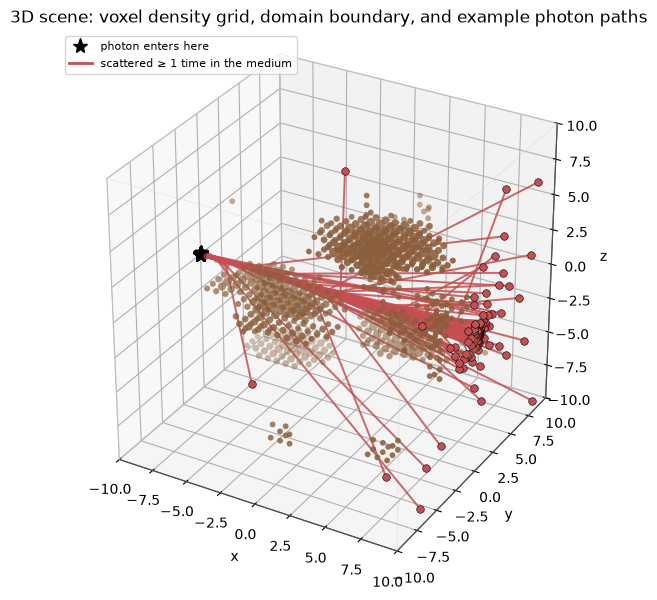

In [23]:
# --- 1. 3D photon trajectories through the FITS-derived cloud (same as Section 7) ---
print("Here I extract 300 random, scattered photons from the simulation dataset.")
print("I get their trajectories and visualize it with the cloud so we can see")
print("what happened.")
example_paths = geometry.extract_example_paths(path, status, n_examples=300, n_scatter=n_scatter)

fig = plt.figure(figsize=(8, 7))
plotting.plot_3d_scene(example_paths, density_grid, box_min, box_max, voxel_alpha=1)
plt.show()



### This is the DSH image. It is not very visible bcs we are not simulating that many photons
### but the structure is there.

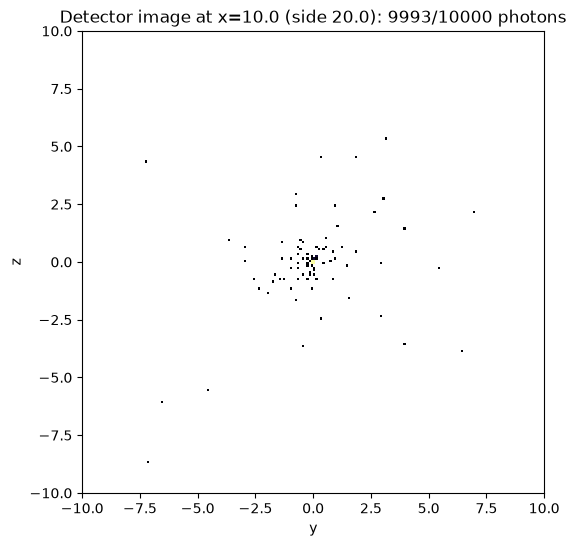

9993/10000 photons landed on the detector


In [ ]:
from utils import imager

fig, ax = plt.subplots(figsize=(6, 6))
ax, n_hit, n_total = imager.render(path, direction, status, side_width=20.0, screen_x=10.0)
plt.show()
print(f"{n_hit}/{n_total} photons landed on the detector")


### Most photons are piled up in the center.

(<Axes: title={'center': 'Detector image at x=10.0 (side 1): 9928/10000 photons'}, xlabel='y', ylabel='z'>,
 9928,
 10000)

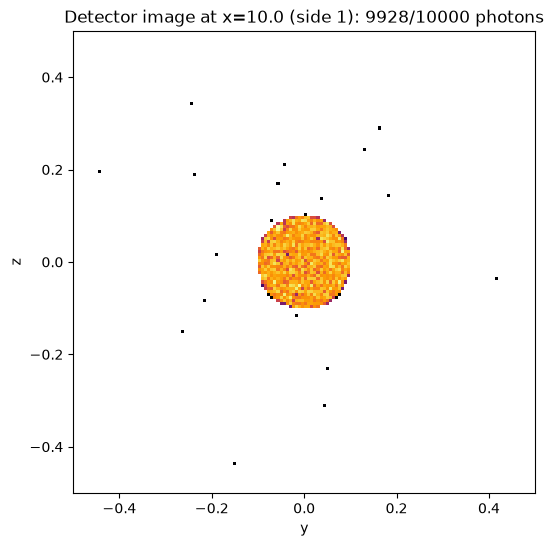

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
imager.render(path, direction, status, side_width=1, screen_x=10.0, bins=150)


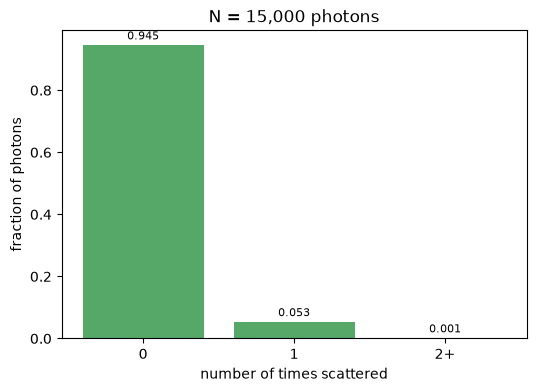

In [45]:
# --- 2. how many times each photon scattered (Section 8) ---
plotting.plot_n_scatter_histogram(n_scatter)
plt.show()



still active (should be close to 0): 0.0000
scattered >= 1 time: 0.0546


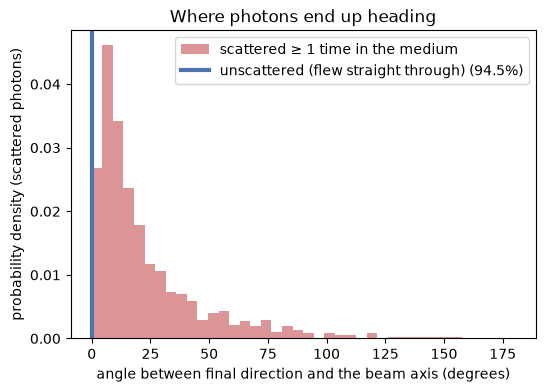

In [46]:
import jax.numpy as jnp
print(f"still active (should be close to 0): {float(jnp.mean(status == transport.ACTIVE)):.4f}")
print(f"scattered >= 1 time: {float(jnp.mean(n_scatter >= 1)):.4f}")

# --- 3. exit-angle distribution: how much photons got redirected (Section 9) ---
plotting.plot_exit_angle_comparison(direction, n_scatter)
plt.show()